<a href="https://colab.research.google.com/github/lakshay0512/BrainWave/blob/main/BrainWave.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from shutil import copyfile
from os import listdir
import cv2
from google.colab.patches import cv2_imshow
from tensorflow.keras.layers import Conv2D, Input, ZeroPadding2D, BatchNormalization, Activation, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model, load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils import shuffle
import imutils
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(len(os.listdir('/content/drive/MyDrive/no')))
print(len(os.listdir('/content/drive/MyDrive/yes')))

98
155


In [ ]:
n = len(os.listdir('/content/drive/MyDrive/no'))
y = len(os.listdir('/content/drive/MyDrive/yes'))
t = (y+n)
y_prec = (y*100.0)/t
n_prec = (n*100.0)/t
print(f"Number of examples: {t}")
print(f"Percentage of positive examples: {y_prec}%, number of pos examples: {y}") 
print(f"Percentage of negative examples: {n_prec}%, number of neg examples: {n}") 

Number of examples: 253
Percentage of positive examples: 61.26482213438735%, number of pos examples: 155
Percentage of negative examples: 38.73517786561265%, number of neg examples: 98


In [ ]:
try:
    os.mkdir('/content/drive/MyDrive/trial1')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/training')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/training/yes1')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/training/no1')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/testing')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/testing/yes1')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/testing/no1')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/yesreal')
    os.mkdir('/content/drive/MyDrive/trial1/augmented data1/noreal')
except OSError:
    pass

In [ ]:
for filename in listdir('/content/drive/MyDrive/yes'):
        image = cv2.imread('/content/drive/MyDrive/yes' + '/' + filename)
        image = image.reshape((1,)+image.shape)
        save_prefix = 'aug_' + filename[:-4]
        print(filename[:-4])
        break

Y103


In [ ]:
def augment_data(file_dir, n_generated_samples, save_to_dir):
    data_gen = ImageDataGenerator(rotation_range=10, 
                                  width_shift_range=0.1, 
                                  height_shift_range=0.1, 
                                  shear_range=0.1, 
                                  brightness_range=(0.3, 1.0),
                                  horizontal_flip=True, 
                                  vertical_flip=True, 
                                  fill_mode='nearest'
                                 )

    
    for filename in listdir(file_dir):
        image = cv2.imread(file_dir + '/' + filename)
        image = image.reshape((1,)+image.shape)
        save_prefix = 'aug_' + filename[:-4]
        i=1
        for batch in data_gen.flow(x=image, batch_size=1, save_to_dir=save_to_dir, 
                                           save_prefix=save_prefix, save_format='jpg'):
            i += 1
            if i > n_generated_samples:
                break

In [ ]:
augmented_data_path = '/content/drive/MyDrive/trial1/augmented data1/'

augment_data(file_dir='/content/drive/MyDrive/yes', n_generated_samples=6, save_to_dir=augmented_data_path+'yesreal')
augment_data(file_dir='/content/drive/MyDrive/no', n_generated_samples=9, save_to_dir=augmented_data_path+'noreal')

In [ ]:
print(len(os.listdir('/content/drive/MyDrive/trial1/augmented data1/noreal')))
print(len(os.listdir('/content/drive/MyDrive/trial1/augmented data1/yesreal')))

980
1084


In [ ]:
n = len(os.listdir('/content/drive/MyDrive/trial1/augmented data1/noreal'))
y = len(os.listdir('/content/drive/MyDrive/trial1/augmented data1/yesreal'))
t = (y+n)
y_prec = (y*100.0)/t
n_prec = (n*100.0)/t
print(f"Number of examples: {t}")
print(f"Percentage of positive examples: {y_prec}%, number of pos examples: {y}") 
print(f"Percentage of negative examples: {n_prec}%, number of neg examples: {n}") 

Number of examples: 2064
Percentage of positive examples: 52.51937984496124%, number of pos examples: 1084
Percentage of negative examples: 47.48062015503876%, number of neg examples: 980


In [ ]:
def crop_brain_contour(image, plot=False):
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)
    c = max(cnts, key=cv2.contourArea)
    # extreme points
    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    new_image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]            

    if plot:
        plt.figure()
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.tick_params(axis='both', which='both', top=False, bottom=False, left=False, right=False,labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Original Image')
        plt.subplot(1, 2, 2)
        plt.imshow(new_image)
        plt.tick_params(axis='both', which='both',top=False, bottom=False, left=False, right=False,labelbottom=False, labeltop=False, labelleft=False, labelright=False)
        plt.title('Cropped Image')
        plt.show()
    
    return new_image

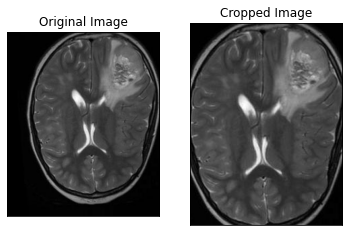

In [ ]:
ex_img = cv2.imread('/content/drive/MyDrive/trial1/augmented data1/yesreal/aug_Y100_0_1291.jpg')
ex_crop_img = crop_brain_contour(ex_img, True)

In [ ]:
X = []
y = []
image_width, image_height = (240, 240)

for directory in ['/content/drive/MyDrive/trial1/augmented data1/yesreal', '/content/drive/MyDrive/trial1/augmented data1/noreal']:
    for filename in listdir(directory):
        image = cv2.imread(directory+'/'+filename)
        image = crop_brain_contour(image, plot=False)
        image = cv2.resize(image, dsize=(image_width, image_height), interpolation=cv2.INTER_CUBIC)
        image = image / 255.
        X.append(image)
        if directory[-7:-4] == 'yes':
            y.append([1])
        else:
            y.append([0])
            
X = np.array(X)
y = np.array(y)

# Shuffle the data
X, y = shuffle(X, y)

print(f'Number of examples is: {len(X)}')
print(f'X shape is: {X.shape}')
print(f'y shape is: {y.shape}')

Number of examples is: 2064
X shape is: (2064, 240, 240, 3)
y shape is: (2064, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))

number of training examples = 1651
number of test examples = 413


In [ ]:
def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
    dataset = []
    
    for unitData in os.listdir(SOURCE):
        data = SOURCE + unitData
        if(os.path.getsize(data) > 0):
            dataset.append(unitData)
        else:
            print('Skipped ' + unitData)
            print('Invalid file i.e zero size')
    
    train_set_length = int(len(dataset) * SPLIT_SIZE)
    test_set_length = int(len(dataset) - train_set_length)
    shuffled_set = random.sample(dataset, len(dataset))
    train_set = dataset[0:train_set_length]
    test_set = dataset[-test_set_length:]
       
    for unitData in train_set:
        temp_train_set = SOURCE + unitData
        final_train_set = TRAINING + unitData
        copyfile(temp_train_set, final_train_set)
    
    for unitData in test_set:
        temp_test_set = SOURCE + unitData
        final_test_set = TESTING + unitData
        copyfile(temp_test_set, final_test_set)
        

split_data('trial1/augmented data1/yesreal/', 'trial1/augmented data1/training/yes1/', 'trial1/augmented data1/testing/yes1/', .8)
split_data('trial1/augmented data1/noreal/', 'trial1/augmented data1/training/no1/', 'trial1/augmented data1/testing/no1/', .8)

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(240, 240, 3)),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 238, 238, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 119, 119, 16)     0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 117, 117, 32)      4640      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 58, 58, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 56, 56, 64)        18496     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 28, 28, 64)      

In [ ]:
TRAINING_DIR = "trial1/augmented data1/training"
train_datagen = ImageDataGenerator(rescale=1.0/255,
                                   rotation_range=40,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(TRAINING_DIR, 
                                                    batch_size=10, 
                                                    class_mode='binary', 
                                                    target_size=(150, 150))
VALIDATION_DIR = "trial1/augmented data1/testing"
validation_datagen = ImageDataGenerator(rescale=1.0/255)

validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR, 
                                                         batch_size=10, 
                                                         class_mode='binary', 
                                                         target_size=(150, 150))

history = model.fit_generator(train_generator,
                              epochs=2,
                              verbose=1,
                              validation_data=validation_generator)

In [ ]:
model.fit(x=X_train, y=y_train, batch_size=3, epochs=15, validation_data=(X_test, y_test))

In [ ]:
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs


plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()


plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.title('Training and validation loss')